In [1]:
"""
Script to fit png from the data.
"""

import logging

import os
from pathlib import Path
import functools

import numpy as np
import matplotlib.pyplot as plt


logger = logging.getLogger('FIT PNG')


# disable jax warning:
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)
logging.getLogger("jax._src.distributed").setLevel(logging.ERROR)
# Remove warning from jax
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'


In [2]:
def read_data(stats_dir='.', tracer='LRG', zrange=(0.4, 1.1), weight_type='default-fkp-oqe', region='GCcomb'):
    import lsstypes
    from clustering_statistics import tools
    import functools 
    
    get_stats_fn = functools.partial(tools.get_stats_fn, stats_dir=stats_dir, tracer=tracer, zrange=zrange, weight=weight_type, region=region)

    # Read the data:
    pk = lsstypes.read(get_stats_fn(kind='mesh2_spectrum'))
    window = lsstypes.read(get_stats_fn(kind='window_mesh2_spectrum'))
    cov = lsstypes.read(get_stats_fn(kind='covariance_mesh2_spectrum'))

    return pk, window, cov

def rebin_data(pk, window, cov, tracer='LRG', kmin=1e-3, kmax=0.08, use_ell2=True):
    tracers = tuple(tracer.split('x')) 
    if len(tracers) == 1: tracers *= 2

    # Let's rebin the power spectrum : 
    # print(f'Original k shape (ell=0): {pk.get(0).k.shape[0]}')
    
    kpivot, nrebin = 2e-2, 2
    pk = pk.map(lambda pole: pole.at(k=(kpivot, 1.)).select(k=slice(0, None, nrebin)))
    # Rebin the quadrupole again but for the full range:
    pk = pk.at(2).select(k=slice(0, None, nrebin))
    
    # kpivot, nrebin = 4e-2, 2
    # pk = pk.map(lambda pole: pole.at(k=(kpivot, 1.)).select(k=slice(0, None, nrebin)))
    # print(f'Rebinned k shape (ell=0): {pk.get(0).k.shape[0]}')

    pk = pk.select(k=(kmin, kmax))
    if not use_ell2: pk = pk.get(ells=[0])
    # print(f'Rebinned k shape (ell=0): {pk.get(0).k.shape[0]}')

    # Match the size of wmatrix and covariance: 
    window = window.at.observable.match(pk)
    cov = cov.at.observable.at(observables='spectrum2', tracers=tracers).match(pk)
    # print(window.value().shape, cov.value().shape)
    
    return pk, window, cov

In [3]:
def plot_observables(observables):
    fig, axs = plt.subplots(2, 2,  figsize=(6, 4), sharex=True, sharey=False, gridspec_kw={'height_ratios': (3, 1)}, squeeze=True)
    fig.subplots_adjust(hspace=0.1)

    for tracer in observables.keys():
        for obs in observables[tracer]:
            j = 1 if 'ell2' in obs.name else 0

            labels = obs.data.labels()
            wtheory = obs.data.clone(value=obs.flattheory)

            for ill, label in enumerate(labels):
                ell = label['ells']
                
                data_pole = obs.data.get()
                wtheory_pole = wtheory.get()
                x = data_pole.coords('k')
                std = obs.covariance.at.observable.get().std()

                scale = 1.
                axs[0, j].errorbar(x, scale * data_pole.value(), yerr=scale * std, linestyle='none', marker='o', markersize=4, label=rf'{tracer}')
                axs[0, j].loglog(x, scale * wtheory_pole.value(), ls='-', c='k')

                axs[1, j].plot(x, (data_pole.value() - wtheory_pole.value()) / std)
                axs[1, j].set_ylim(-4, 4)
                for offset in [-2., 2.]: axs[1, j].axhline(offset, color='k', linestyle='--')

    axs[0, 0].set_ylim(1e4, 8e4)
    axs[0, 1].set_ylim(2e3, 5e4)

    axs[0, 0].legend()
    axs[0, 1].legend()
    axs[0, 0].set_title(r'$\ell = 0$', fontsize=10)
    axs[0, 1].set_title(r'$\ell = 2$', fontsize=10)
    axs[0, 0].set_ylabel(r'$P_{\ell}(k)$ [$(\mathrm{Mpc}/h)^{3}$]')
    axs[1, 0].set_ylabel(r'$\Delta P_{\ell} / \sigma (P_{\ell})$')
    axs[1, 0].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
    axs[1, 1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')

    plt.tight_layout()
    plt.show()

def run_profiler(likelihood, output_name=None):
    from desilike.profilers import MinuitProfiler

    profiler = MinuitProfiler(likelihood, seed=7)
    profiler.maximize(niterations=20)
    logger.info(f'\n{profiler.profiles.to_stats(tablefmt="pretty")}')

    # Save information: 
    if output_name is not None:
        _ = profiler.profiles.to_stats(fn=f'./profiles/tex_ready_{output_name}.txt')
        np.savetxt(f'./profiles/{output_name}.txt', profiler.profiles.to_stats(tablefmt='list')[0], fmt='%s')


def run_mcmc(likelihood, fn_output='tmp/mcmc_output_*.npy', extend_chains=False, nchains=1, max_iterations=1e5):
    from desilike.samplers import EmceeSampler
    chains = [fn_output.replace('*', f'{i}') for i in range(nchains)] if extend_chains else nchains

    sampler = EmceeSampler(likelihood, seed=31, chains=chains, save_fn=fn_output)  
    sampler.run(max_iterations=max_iterations)

    return sampler


def get_getdist_plotter(fig_width_inch=5, fontsize=14, legend_fontsize=12, axes_labelsize=12, axes_fontsize=14, line_lables=True):
    from getdist import plots as gdplt

    plotter = gdplt.get_subplot_plotter()
    plotter.settings.fig_width_inch = fig_width_inch
    plotter.settings.fontsize = fontsize
    plotter.settings.legend_fontsize = legend_fontsize
    plotter.settings.axes_labelsize = axes_labelsize
    plotter.settings.axes_fontsize = axes_fontsize
    plotter.settings.line_labels = line_lables
    plotter.settings.alpha_filled_add = 0.8
    plotter.settings.legend_loc = 'upper right'
    plotter.settings.figure_legend_ncol = 1
    plotter.settings.legend_colored_text = False

    return plotter


def plot_triangle(chains, params, legend_labels=None, xlabels=[r'$f_{\rm NL}^{\rm loc}$', r'$b_1$', r'$s_{n,0}$', r'$\Sigma_s$'], 
                  contour_colors=None, filled=True, contour_ls=None, g=None, fn=None):
    from desilike.samples import plotting
    
    if g is None: g = get_getdist_plotter()
    plotting.plot_triangle(chains, params, legend_labels=legend_labels, 
                           contour_colors=contour_colors, filled=filled, contour_ls=contour_ls, 
                           g=g, show=False, fn=None)

    if xlabels is not None:
        for i in range(len(xlabels)):
            g.subplots[len(xlabels)-1, i].set_xlabel(xlabels[i])
            if i > 0:
                g.subplots[i, 0].set_ylabel(xlabels[i])

    if fn is not None: plt.savefig(fn)
    plt.show()

In [4]:
def get_obervable_and_likelihood(pk, window, cov, tracer, p={'LRG': 1., 'ELG': 1., 'QSO': 1.4}, fix_fnl=False, **kwargs):
    from desilike.theories.galaxy_clustering import FixedPowerSpectrumTemplate, PNGTracerPowerSpectrumMultipoles
    from desilike.observables.galaxy_clustering import TracerPowerSpectrumMultipolesObservable
    from desilike.likelihoods import ObservablesGaussianLikelihood

    tracers = tuple(tracer.split('x'))
    cross_correlation = True
    if len(tracers) == 1: 
        tracers *= 2
        cross_correlation = False

    observables = []
    zeff = []

    for ell in pk.ells:
        zeff.append(window.observable.get(ell).attrs['zeff'])   
        if cross_correlation: 
            tracers_theo = [tracer + f'_cross_ell{ell}' for tracer in tracers]
        else:
            tracers_theo = [tracer + f'_ell{ell}' for tracer in tracers]
        if not cross_correlation: tracers_theo = tracers_theo[:1]
        logger.info(f'{tracers_theo=}, {ell=}, zeff={zeff[-1]:2.4}')

        data = pk.get(ells=[ell])
        # extract only the mulitpole ell: 
        wmatrix = window.at.observable.match(data)
        covariance = cov.at.observable.at(observables='spectrum2', tracers=tracers).match(data)
        # subselect only the covariance for the cross-tracers (if tracer is a cross-tracer):
        covariance = covariance.at.observable.get(observables='spectrum2', tracers=tracers)
        
        # data, wmatrix, covariance live in this loop:
        # print(data.value().shape, wmatrix.value().shape, covariance.value().shape)
        # print(np.linalg.inv(cov.value()))

        template = FixedPowerSpectrumTemplate(z=zeff[-1], fiducial='DESI')
        theory = PNGTracerPowerSpectrumMultipoles(template=template, mode="b-p", tracers=tracers_theo)
        
        theory.params['fnl_loc'].update(value=0.0, fixed=fix_fnl)
        if ell == 2: theory.params[f"{'x'.join(tracers_theo)}.sn0"].update(value=0, fixed=True)
        for tracer in tracers_theo:
            theory.params[f'{tracer}.p'].update(value=p[tracer.split('_')[0]], fixed=True)

        # Don't forget to give different name for the observable in order to stack them together in the likelihood:
        observables += [TracerPowerSpectrumMultipolesObservable(name=f'pk_{tracer}', data=data, window=wmatrix, covariance=covariance, theory=theory)] 

    likelihood = ObservablesGaussianLikelihood(observables=observables, covariance=cov.at.observable.get(tracers=tracers).value(), scale_covariance=1)

    if len(pk.ells) > 1:
        from clustering_statistics import tools
        # let ell2.b1 be derived by ell0.b1: 
        for tracer in np.unique(tracers_theo):
            alpha, beta = tools.bias(1, tracer=tracer.split('_')[0], return_params=True)  # b(z) = alpha * (1 + z)**2 + beta
            factor = (alpha * (1 + zeff[1])**2 + beta) / (alpha * (1 + zeff[0])**2 + beta)
            likelihood.all_params[f"{tracer.split('_ell')[0]}_ell2.b1"].update(derived='{' + f"{tracer.split('_ell')[0]}_ell0.b1" + '}' + f' * {factor}')
            logger.warning('we neglect the redshift dependence of the damping term, for now')
            likelihood.all_params[f"{tracer.split('_ell')[0]}_ell2.sigmas"].update(derived='{' + f"{tracer.split('_ell')[0]}_ell0.sigmas" + '}')
        
    if cross_correlation: 
        if f"{tracers_theo[0].split('_ell')[0]}_ell0.b1" in kwargs:
            default_b1 = kwargs[f"{tracers_theo[0].split('_ell')[0]}_ell0.b1"] 
        else:
            default_b1 = 1
        likelihood.all_params[f"{tracers_theo[0].split('_ell')[0]}_ell0.b1"].update(value=default_b1, fixed=True)    
        likelihood.all_params[f"{tracers_theo[0].split('_ell')[0]}_ell0.sigmas"].update(value=0, fixed=True)

    likelihood()

    return observables, likelihood

In [5]:
from clustering_statistics import setup_logging

from mpi4py import MPI
setup_logging(level=(logging.INFO if MPI.COMM_WORLD.rank == 0 else logging.ERROR))

stats_dir = Path(os.getenv('SCRATCH', '.')) / 'DR2_local_png' / 'measurements' / 'loa-v1/v2/fNL'
if True:
    stats_dir = stats_dir / 'blinded'
else:
    logger.error('NOT READY FOR UNBLINDED DATA YET')
    import sys
    sys.exit(3)

logger.info(f'Load data from: stats_dir: {stats_dir}')

kmin, kmax = 1e-3, 0.08

use_ell2 = True
region = 'GCcomb'
tracers = ['LRG', 'QSO', 'LRGxQSO']
weight_type = ['default-fkp-oqe'] * 3
zrange = [(0.4, 1.1), (0.8, 3.5), (0.8, 1.1)]  # We neglect the correlation induces by cross mode 'below 0.8' or 'above 1.1'

kwargs = {'LRG_cross_ell0.b1': 2.15}

pks, windows, covs = {}, {}, {}
observables, likelihoods = {}, {}

for tracer, weight_type, zrange in zip(tracers, weight_type, zrange):

    pk, window, cov = read_data(stats_dir=stats_dir, tracer=tracer, zrange=zrange, weight_type=weight_type, region=region)
    pk, window, cov = rebin_data(pk, window, cov, tracer=tracer, kmin=kmin, kmax=kmax, use_ell2=use_ell2)
    observable, likelihood = get_obervable_and_likelihood(pk, window, cov, tracer, **kwargs)

    run_profiler(likelihood)

    pks[tracer] = pk
    windows[tracer] = window
    covs[tracer] = cov
    observables[tracer] = observable
    likelihoods[tracer] = likelihood

[000000.00] [0/1] 03-26 14:42  FIT PNG                   INFO     Load data from: stats_dir: /pscratch/sd/e/edmondc/DR2_local_png/measurements/loa-v1/v2/fNL/blinded
✅ Using NumPy with CPU.
[000004.28] [0/1] 03-26 14:42  FIT PNG                   INFO     tracers_theo=['LRG_ell0'], ell=0, zeff=0.8178
[000004.51] [0/1] 03-26 14:42  FIT PNG                   INFO     tracers_theo=['LRG_ell2'], ell=2, zeff=0.8358
[000007.56] [0/1] 03-26 14:42  FIT PNG                   WARNING  we neglect the redshift dependence of the damping term, for now
[000009.60] [0/1] 03-26 14:42  MinuitProfiler            INFO     Varied parameters: ['fnl_loc', 'LRG_ell0.sn0', 'LRG_ell0.b1', 'LRG_ell0.sigmas'].
[000010.55] [0/1] 03-26 14:42  MinuitProfiler            INFO     Successfully jit input likelihood.
[000016.77] [0/1] 03-26 14:42  FIT PNG                   INFO     
+-------------------------------------+--------+---------+-------+
| chi2 / (74 - 4) = 76.45 / 70 = 1.09 | varied | bestfit | error |
+------

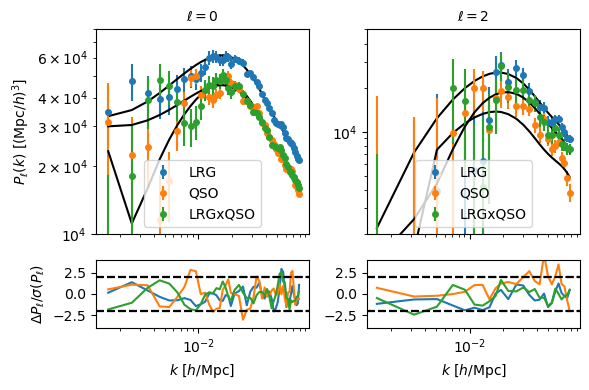

In [6]:
plot_observables(observables)

In [7]:
sampler = run_mcmc(likelihoods['LRGxQSO'], max_iterations=10000)

[000040.77] [0/1] 03-26 14:43  EmceeSampler              INFO     Varied parameters: ['fnl_loc', 'LRG_cross_ell0xQSO_cross_ell0.sn0', 'QSO_cross_ell0.b1', 'QSO_cross_ell0.sigmas'].
[None]
[000043.17] [0/1] 03-26 14:43  EmceeSampler              INFO     Successfully vmap input likelihood.
[000043.65] [0/1] 03-26 14:43  EmceeSampler              INFO     Successfully jit input likelihood.
[000049.51] [0/1] 03-26 14:43  Chain                     INFO     Saving tmp/mcmc_output_0.npy.


[000054.91] [0/1] 03-26 14:43  Chain                     INFO     Saving tmp/mcmc_output_0.npy.
[000059.28] [0/1] 03-26 14:43  Chain                     INFO     Saving tmp/mcmc_output_0.npy.
[000063.89] [0/1] 03-26 14:43  Chain                     INFO     Saving tmp/mcmc_output_0.npy.
[000068.65] [0/1] 03-26 14:43  Chain                     INFO     Saving tmp/mcmc_output_0.npy.
[000073.30] [0/1] 03-26 14:43  Chain                     INFO     Saving tmp/mcmc_output_0.npy.
[000077.76] [0/1] 03-26 14:43  Chain                     INFO     Saving tmp/mcmc_output_0.npy.
[000082.18] [0/1] 03-26 14:44  Chain                     INFO     Saving tmp/mcmc_output_0.npy.
[000086.84] [0/1] 03-26 14:44  Chain                     INFO     Saving tmp/mcmc_output_0.npy.
[000091.25] [0/1] 03-26 14:44  Chain                     INFO     Saving tmp/mcmc_output_0.npy.
[000095.72] [0/1] 03-26 14:44  Chain                     INFO     Saving tmp/mcmc_output_0.npy.
[000099.96] [0/1] 03-26 14:44  Chain    

Removed no burn in
[000195.52] [0/1] 03-26 14:45  root                      WARNING  fine_bins_2D not large enough for optimal density: fnl_loc, QSO_cross_ell0.b1
[000195.65] [0/1] 03-26 14:45  root                      WARNING  fine_bins_2D not large enough for optimal density: fnl_loc, LRG_cross_ell0xQSO_cross_ell0.sn0


[000195.72] [0/1] 03-26 14:45  root                      WARNING  fine_bins_2D not large enough for optimal density: fnl_loc, QSO_cross_ell0.sigmas
[000195.94] [0/1] 03-26 14:45  root                      WARNING  fine_bins_2D not large enough for optimal density: QSO_cross_ell0.b1, QSO_cross_ell0.sigmas
[000196.01] [0/1] 03-26 14:45  root                      WARNING  fine_bins_2D not large enough for optimal density: LRG_cross_ell0xQSO_cross_ell0.sn0, QSO_cross_ell0.sigmas


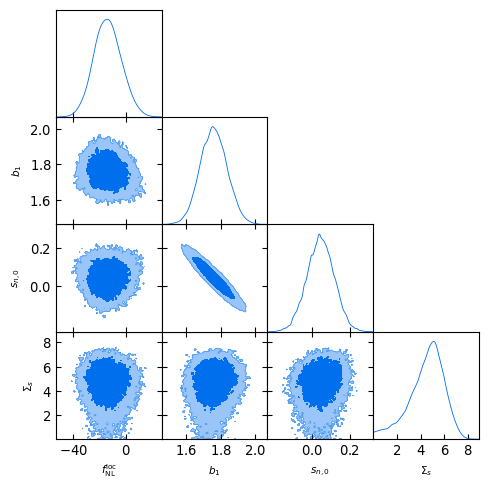

In [8]:
from desilike.samples import Chain

burnin, thin = 0.3, 50

#chains = Chain.concatenate([Chain.load(fn_chains_QSO_data_binded[key].format('_with_RIC', '_w_oqe_p_1.6_new_bias').replace('*', str(i))).remove_burnin(burnin)[::thin] for i in range(8)])

chains = Chain.concatenate(sampler.chains)
plot_triangle(chains, ['fnl_loc', 'QSO_cross_ell0.b1', 'LRG_cross_ell0xQSO_cross_ell0.sn0', 'QSO_cross_ell0.sigmas'])

In [9]:
use_ell2 = True
region = 'GCcomb'
tracers = ['QSO']
weight_type = ['default-fkp-oqe'] 
zrange = [(0.8, 3.5)]  # We neglect the correlation induces by cross mode 'below 0.8' or 'above 1.1'

for tracer, weight_type, zrange in zip(tracers, weight_type, zrange):

    pk, window, cov = read_data(stats_dir=stats_dir, tracer=tracer, zrange=zrange, weight_type=weight_type, region=region)
    pk, window, cov = rebin_data(pk, window, cov, tracer=tracer, kmin=kmin, kmax=kmax, use_ell2=use_ell2)
    observable, likelihood = get_obervable_and_likelihood(pk, window, cov, tracer, **kwargs)

    run_profiler(likelihood)

[000221.98] [0/1] 03-26 14:46  FIT PNG                   INFO     tracers_theo=['QSO_ell0'], ell=0, zeff=2.125
[000222.10] [0/1] 03-26 14:46  FIT PNG                   INFO     tracers_theo=['QSO_ell2'], ell=2, zeff=2.313


[000224.74] [0/1] 03-26 14:46  FIT PNG                   WARNING  we neglect the redshift dependence of the damping term, for now
[000224.90] [0/1] 03-26 14:46  MinuitProfiler            INFO     Varied parameters: ['fnl_loc', 'QSO_ell0.sn0', 'QSO_ell0.b1', 'QSO_ell0.sigmas'].
[000225.55] [0/1] 03-26 14:46  MinuitProfiler            INFO     Successfully jit input likelihood.
[000233.72] [0/1] 03-26 14:46  FIT PNG                   INFO     
+--------------------------------------+--------+---------+-------+
| chi2 / (74 - 4) = 134.65 / 70 = 1.92 | varied | bestfit | error |
+--------------------------------------+--------+---------+-------+
|               fnl_loc                |  True  |  -8.3   |  2.0  |
|             QSO_ell0.sn0             |  True  | -0.289  | 0.039 |
|             QSO_ell0.b1              |  True  |  3.272  | 0.034 |
|           QSO_ell0.sigmas            |  True  |   0.0   |  5.8  |
|             QSO_ell2.b1              |  True  |   3.6   |       |
|         

In [10]:
from clustering_statistics import tools
print(tools.bias(2.125, tracer='QSO'))
print(tools.bias(2.313, tracer='QSO'))

3.1718840317187507
3.4769820643804303


In [11]:
from desilike.theories.galaxy_clustering import FixedPowerSpectrumTemplate, PNGTracerPowerSpectrumMultipoles
from desilike.observables.galaxy_clustering import TracerPowerSpectrumMultipolesObservable
from desilike.likelihoods import ObservablesGaussianLikelihood

template = FixedPowerSpectrumTemplate(z=2.313, fiducial='DESI')
theory = PNGTracerPowerSpectrumMultipoles(template=template, mode="b-p")

theory.params['fnl_loc'].update(value=0.0, fixed=True)
theory.params['p'].update(value=1.4, fixed=True)


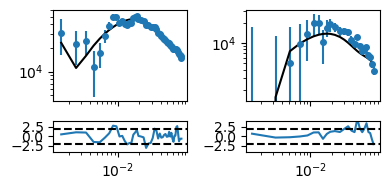

In [14]:
fig, axs = plt.subplots(2, 2,  figsize=(4, 2), sharex=True, sharey=False, gridspec_kw={'height_ratios': (3, 1)}, squeeze=True)
fig.subplots_adjust(hspace=0.1)

for obs in observable:
    j = 1 if 'ell2' in obs.name else 0

    labels = obs.data.labels()
    wtheory = obs.data.clone(value=obs.flattheory)

    for ill, label in enumerate(labels):
        ell = label['ells']
        
        data_pole = obs.data.get()
        wtheory_pole = wtheory.get()
        x = data_pole.coords('k')
        std = obs.covariance.at.observable.get().std()

        scale = 1.
        axs[0, j].errorbar(x, scale * data_pole.value(), yerr=scale * std, linestyle='none', marker='o', markersize=4, label=rf'{tracer}')
        axs[0, j].loglog(x, scale * wtheory_pole.value(), ls='-', c='k')

        axs[1, j].plot(x, (data_pole.value() - wtheory_pole.value()) / std)
        axs[1, j].set_ylim(-4, 4)
        for offset in [-2., 2.]: axs[1, j].axhline(offset, color='k', linestyle='--')

plt.tight_layout()
plt.show()


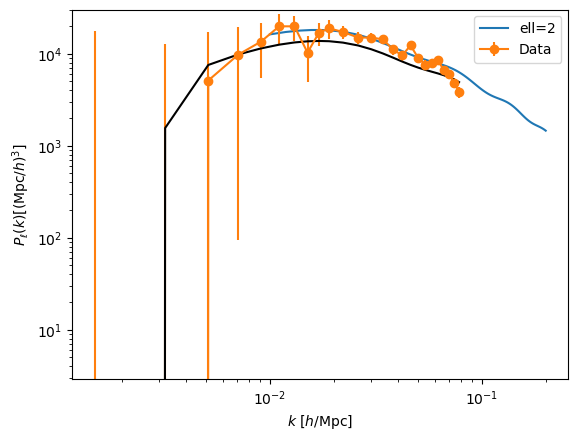

In [ ]:
#plt.loglog(theory.k, theory(b1=2.2, sigmas=0, sn0=0)[0,:], label='ell=0')
plt.loglog(theory.k, theory(b1=3.6, sigmas=0, sn0=0)[1,:], label='ell=2')

plt.loglog(theory.k, theory(b1=3.2, sigmas=0, sn0=0)[1,:], label='ell=2 with b1 from ell=0')


data_pole = observable[1].data.get()
x = data_pole.coords('k')
plt.errorbar(x, data_pole.value(), yerr=std, marker='o', label='Data')

wtheory = observable[1].data.clone(value=observable[1].flattheory)
wtheory_pole = wtheory.get()
plt.loglog(x,  wtheory_pole.value(), ls='-', c='k')


plt.legend()
plt.xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
plt.ylabel(r'$P_{\ell}(k) [(\mathrm{Mpc}/h)^{3}]$')
plt.show()

In [16]:
wtheory

Mesh2SpectrumPoles(labels=[{'ells': 2}], size=25)

In [ ]:
# We do not link the damping term from the cross-correlation and the auto-correlation
# Because they are different effective redshifts and we do not know the a priori.


In [19]:
# Build the total analytical covariance :
# Use .match function to apply the same selection for each part of the covariance matrix in cov['LRGxQSO']

from lsstypes import ObservableTree

_tracer_split = [('LRG', 'LRG'), ('LRG', 'QSO'), ('QSO', 'QSO')]
_observables = ['spectrum2', 'spectrum2', 'spectrum2']
pk_join = [pks['LRG'], pks['LRGxQSO'], pks['QSO']]

super_observable = ObservableTree(pk_join, observables=_observables, tracers=_tracer_split)
super_cov = covs['LRGxQSO'].copy()

# Smart enough that it directly apply the same cut and rebin that each pk:
super_cov = super_cov.at.observable.match(super_observable).value()

print(super_cov.shape)
print(np.sum([pk.size for pk in pk_join]))

#plt.plot(np.diag(super_cov))

# Update with the covariance of the auto-correlations. We neglect the cross-mode. 
super_cov[:pks['LRG'].size, :pks['LRG'].size] = covs['LRG'].value()
super_cov[-pks['QSO'].size:, -pks['QSO'].size:] = covs['QSO'].value()

#plt.plot(np.diag(super_cov), ls='--')

(222, 222)
222


In [20]:
# how will we do with the mocks? (I think nothing, it will straight forwards, like providing the mocks for each obseravble and desilike will take the standard deviation ect... ) --> no PROBLEME

flatten_observables = [observable for tracer in tracers for observable in observables[tracer]]  # inefficient for large list, here ok ... 

from desilike.likelihoods import ObservablesGaussianLikelihood
total_likelihood = ObservablesGaussianLikelihood(observables=flatten_observables, covariance=super_cov, scale_covariance=1)

for tracer in tracers: 
    tt = tuple(tracer.split('x')) 
    if len(tt) == 1: tt *= 2

    if len(pks[tracer].ells) > 1:
        from clustering_statistics import tools
        # let ell2.b1 be derived by ell0.b1: 
        if tt[0] != tt[1]: logger.warning(f'We use the bias evolution of {tt[0]} (that should be ok -> be careful when using auto + cross together')

        zeff = [windows[tracer].observable.get(ell).attrs['zeff'] for ell in [0,2]]
        alpha, beta = tools.bias(1, tracer=tt[0], return_params=True)  # b(z) = alpha * (1 + z)**2 + beta
        factor = (alpha * (1 + zeff[1])**2 + beta) / (alpha * (1 + zeff[0])**2 + beta)
        total_likelihood.all_params[f'{tracer}_ell2.b1'].update(derived='{' + f'{tracer}_ell0.b1' + '}' + f' * {factor}')

logger.info(total_likelihood.varied_params)

total_likelihood()



[000062.46] [0/1] 03-20 08:36  FIT PNG                   WARNING  We use the bias evolution of LRG (that should be ok -> be careful when using auto + cross together


/global/u2/e/edmondc/Software/desilike/desilike/parameter.py:1011: SyntaxWarning: invalid escape sequence '\m'
  latex_namespace = namespace if provided_namespace else ('\mathrm{%s}' % namespace.replace('\_', '_').replace('_', '\_'))
/global/u2/e/edmondc/Software/desilike/desilike/parameter.py:1011: SyntaxWarning: invalid escape sequence '\_'
  latex_namespace = namespace if provided_namespace else ('\mathrm{%s}' % namespace.replace('\_', '_').replace('_', '\_'))
/global/u2/e/edmondc/Software/desilike/desilike/parameter.py:1011: SyntaxWarning: invalid escape sequence '\_'
  latex_namespace = namespace if provided_namespace else ('\mathrm{%s}' % namespace.replace('\_', '_').replace('_', '\_'))


KeyError: 'Parameter LRGxQSO_ell2.b1 not found'

In [26]:
run_profiler(total_likelihood)
for obs in observables:
    _ = obs.plot(scaling='loglog', show=True, figsize=(4, 4))

[000870.98] [0/1] 03-16 16:09  MinuitProfiler            INFO     Varied parameters: ['fnl_loc', 'LRGxQSO.sn0', 'LRGxQSO.sigmas', 'LRGxQSO_ell0.b1', 'QSO.sn0', 'QSO.sigmas', 'QSO_ell0.b1', 'LRG.sn0', 'LRG.sigmas', 'LRG_ell0.b1'].
[000872.05] [0/1] 03-16 16:09  MinuitProfiler            INFO     Successfully jit input likelihood.
E VariableMetricBuilder Initial matrix not pos.def.
E VariableMetricBuilder Initial matrix not pos.def.
E VariableMetricBuilder Initial matrix not pos.def.
E VariableMetricBuilder Initial matrix not pos.def.
E VariableMetricBuilder Initial matrix not pos.def.
E VariableMetricBuilder Initial matrix not pos.def.
E VariableMetricBuilder Initial matrix not pos.def.
E VariableMetricBuilder Initial matrix not pos.def.
E VariableMetricBuilder Initial matrix not pos.def.
E VariableMetricBuilder Initial matrix not pos.def.
E VariableMetricBuilder Initial matrix not pos.def.
E VariableMetricBuilder Initial matrix not pos.def.
E VariableMetricBuilder Initial matrix not po

AttributeError: 'str' object has no attribute 'plot'

In [ ]:
https://github.com/cosmodesi/desi-clustering/blob/7b1f38fcacbfa4ef815f56c345b5072f2a3a7d26/full_shape/tools.py#L301

In [ ]:
## IMPORTANT COMMENT FAIRE POUR HARTLPA/PERCIVAL -> COMMENT DESILIKE DONNE LES VAEURS DE CHI2 (qui ne doit pas avoir percival) mais le 